<a href="https://colab.research.google.com/github/zFonta/CEIA-TF-Chess-DL/blob/main/notebooks/07_transformer_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 - Ajuste del transformer

Cierre de la tarea **4.8**: la primera campaña del transformer quedó en 0,2978
sobre test contra los 0,2511 de la ResNet, y el diagnóstico dice por qué.

## El transformer no sobreajusta: subajusta

| época | transformer train / val / **razón** | ResNet c2 train / val / **razón** |
|---|---|---|
| 10 | 0,0997 / 0,3168 / **1,01** | 0,0527 / 0,2611 / **1,29** |
| 20 | 0,0835 / 0,2988 / **1,07** | 0,0270 / 0,2501 / **2,32** |
| 30 | 0,0759 / 0,2999 / **1,19** | 0,0172 / 0,2539 / **3,75** |

Una razón cercana a 1 significa que el error de validación y el de entrenamiento
son prácticamente el mismo número: no hay nada memorizado, y por lo tanto nada
sobre-aprendido. Al modelo no le sobra capacidad, le falta ajuste.

El dato que lo cierra es más contundente todavía: **la pérdida de entrenamiento
final del transformer (0,0759) es peor que el error de validación de la ResNet
en su mejor época (0,0622).** No consigue ajustar el set de entrenamiento tan
bien como la ResNet generaliza.

## La causa fueron los hiperparámetros, no la arquitectura

La campaña 1 corrió con `lr` 3e-4 —un tercio del de la ResNet— y `weight_decay`
1e-2, **cien veces el de la ResNet**. Las dos decisiones se tomaron como seguro
contra la inestabilidad típica de los transformers, y las dos empujan al
subajuste. La curva muestra que el seguro nunca hizo falta: treinta épocas
monótonas, sin un solo pico. Encima el coseno apagó el learning rate cuando la
pérdida todavía bajaba (de la época 20 a la 30 cayó 9,2 % y la validación quedó
clavada).

## Los tres brazos

Tres técnicas distintas, no tres learning rates. Cada uno se apoya en el
anterior: el diagnóstico apunta en una sola dirección y no hay presupuesto para
cruzarlos.

| brazo | qué cambia | por qué |
|---|---|---|
| `receta-resnet` | lr 1e-3, wd 1e-4, sin dropout, recorte de gradiente | El control, y la comparación más limpia posible: la receta **exacta** de la ResNet |
| `lotes-chicos` | lote 512 en vez de 1024 | 4.488 pasos de optimización por época en lugar de 2.244 |
| `pooling-medio` | promedio de las 64 casillas en vez del token CLS | Único brazo que toca la red: da a cada casilla un camino directo al gradiente |

El **recorte de gradiente** (`grad_clip=1.0`) es nuevo en la librería y va en los
tres. No está ahí por seguridad en abstracto: es lo que convierte el salto de
learning rate ×3,3 en algo razonable de probar en una red que no tiene batch
normalization para acotar sus activaciones.

> **Sobre `lotes-chicos`, dicho claro:** el tamaño de lote y el learning rate
> están acoplados, y partir el lote a la mitad manteniendo la tasa sube el paso
> efectivo *y* el ruido del gradiente a la vez. No es un eje limpio: es otra
> forma de gastar el mismo presupuesto. Si gana, la lectura honesta es "más
> pasos, más ruidosos, ayudaron", no "512 es el lote correcto".

**Referencias a batir** (validación): piso de material 0,3973 · transformer
campaña 1 **0,2981** · ResNet campaña 2 **0,2494**.

## 1. Entorno

In [2]:
# Clonar el repositorio e instalar el paquete.
# Idempotente: se puede volver a correr tal cual despues de una desconexion.
import os, sys, subprocess, importlib
from pathlib import Path

REPO_DIR = Path("/content/CEIA-TF-Chess-DL")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/zFonta/CEIA-TF-Chess-DL.git", str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], check=True)

# pip registra el paquete editable con un .pth, y los .pth solo se procesan al
# arrancar el interprete: un kernel que ya esta corriendo no lo ve. Agregar src/
# a sys.path lo hace visible sin tener que reiniciar el runtime.
src = str(REPO_DIR / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()

# Stockfish con version fija. Entrenar no lo usa, pero sin el se saltean los 17
# tests de integracion del pipeline, que son la evidencia del requerimiento 3.2.
subprocess.run(["bash", "scripts/setup_stockfish.sh"], check=True)
os.environ["PATH"] = f"{REPO_DIR}/bin:" + os.environ["PATH"]

print("Listo. Directorio de trabajo:", os.getcwd())

Listo. Directorio de trabajo: /content/CEIA-TF-Chess-DL


In [3]:
import numpy as np
import torch
from chessdl.colab import TRAINING, describe_runtime

runtime = describe_runtime(phase=TRAINING)
print("GPU  :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU")
for aviso in runtime.warnings():
    print("AVISO:", aviso)

GPU  : Tesla T4


## 2. Tests

In [3]:
!{sys.executable} -m pytest -q

........................................................................ [ 17%]
........................................................................ [ 35%]
........................................................................ [ 53%]
........................................................................ [ 70%]
........................................................................ [ 88%]
...............................................                          [100%]
407 passed in 71.58s (0:01:11)


## 3. Dataset, partición, caché y pisos

Idéntico a las notebooks 04, 05 y 06. Si el caché ya está en disco no se
reconstruye.

In [4]:
from chessdl.config import load_config
from chessdl import hf
from chessdl.data import schema
from chessdl.training.split import describe_split, leaked_games, split_masks
from chessdl.training.cache import build_cache, cache_path_for, load_cache
from chessdl.training.baselines import material_baseline, mean_baseline

cfg = load_config()
token = hf.get_token()
directorio = hf.download_dataset(cfg.output.hf_repo_id, "/content/ceia-chess/hub")
tabla = schema.read_dataset(schema.shard_paths(directorio))

fens     = tabla["fen"].to_pylist()
game_ids = tabla["game_id"].to_pylist()
targets  = np.asarray(tabla["value_stm"], dtype=np.float32)

split_cfg = cfg.training.split_config()
masks = split_masks(game_ids, split_cfg)
assert not leaked_games(masks, game_ids)
print(describe_split(masks, game_ids))

ruta_cache = cache_path_for(cfg.training.cache_dir)
if not ruta_cache.exists():
    build_cache(fens, ruta_cache, progress=True)
cache = load_cache(ruta_cache, expected_rows=len(fens))

idx_train = np.flatnonzero(masks['train'])
idx_val   = np.flatnonzero(masks['val'])
idx_test  = np.flatnonzero(masks['test'])

rng = np.random.default_rng(0)
sub = np.sort(rng.choice(idx_train, size=min(200_000, len(idx_train)), replace=False))
media = mean_baseline(targets[idx_train], targets[idx_val])
material, _ = material_baseline(np.asarray(cache[sub]), targets[sub],
                                np.asarray(cache[idx_val]), targets[idx_val])
pisos = {'media': media.rmse, 'material': material.rmse}
print(media); print(material)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 158 files:   0%|          | 0/158 [00:00<?, ?it/s]

split       posiciones       %    partidas
------------------------------------------
train        2,297,785  90.01%     695,480
val            127,520   5.00%      38,654
test           127,499   4.99%      38,663


encoding:   0%|          | 0/2552804 [00:00<?, ?pos/s]

media constante             RMSE 0.4886   MAE 0.3778
material (lineal)           RMSE 0.3973   MAE 0.3052


## 4. El barrido (3 brazos)

**Presupuesto de cribado: 15 épocas por brazo**, el mismo que usó el barrido de
la ResNet en la tarea 4.5. A ~12,4 minutos por época son unas 10 horas para los
tres. El calentamiento es de 2 épocas, también como el de la ResNet.

### Cómo leer esta tabla: el cribado corto favorece a dos de los tres brazos

En el barrido de la ResNet la advertencia era que menos entrenamiento favorece a
menos regularización. Acá los tres brazos tienen **la misma** regularización, así
que ese sesgo no aplica — pero hay otro, y apunta justo a lo que se quiere medir:

- **`lotes-chicos`** hace el doble de pasos de optimización por época: 67.320
  actualizaciones en las 15 épocas contra 33.660 de los otros dos. Con
  presupuesto corto, cuando ningún brazo convergió, más pasos es más progreso.
  Esa ventaja se comprime a medida que los demás se acercan a su meseta.
- **`pooling-medio`** da gradiente directo a las 64 casillas, así que es
  razonable que **aprenda más rápido al principio** aunque el token CLS lo
  alcance más tarde.

O sea: si gana uno de esos dos por poco, no se puede distinguir "la técnica es
mejor" de "el cribado la premia". Por eso el ganador se **confirma a 30 épocas**
en la sección 6, y por eso la tabla de más abajo reporta también los pasos de
optimización de cada brazo, que es la variable que el RMSE esconde.

> **Es reanudable.** Cada brazo tiene su propio nombre de corrida en el Hub. Si
> Colab corta a mitad, se vuelve a correr esta celda: los brazos terminados se
> detectan y se saltean, y el que quedó a medias sigue desde su última época.

In [5]:
from chessdl.training.experiments import DEFAULT_TRANSFORMER_SWEEP, run_sweep, transformer_summary

for e in DEFAULT_TRANSFORMER_SWEEP:
    print(f'{e.name:<16}{e.rationale}')
    print(f'{"":16}-> {e.overrides()}' + (f' + pooling {dict(e.architecture)["pooling"]}'
                                          if e.architecture else ''))

receta-resnet   la receta de la ResNet: lr 1e-3, wd 1e-4, sin dropout, con recorte
                -> {'learning_rate': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 2, 'grad_clip': 1.0}
lotes-chicos    lote 512: el doble de pasos de optimizacion por epoca
                -> {'batch_size': 512, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 2, 'grad_clip': 1.0}
pooling-medio   promedio de las 64 casillas en vez del token CLS
                -> {'learning_rate': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 2, 'grad_clip': 1.0} + pooling mean


In [6]:
from chessdl.models.transformer import ChessTransformer, TransformerConfig

EPOCAS_BARRIDO = 15   # el mismo presupuesto de cribado que uso la ResNet en 4.5
REFERENCIA = 0.2981   # mejor validacion del transformer, campana 1

# La misma arquitectura de la campana 1, para que el barrido mida el
# entrenamiento y no un modelo distinto. El brazo de pooling la modifica.
arquitectura = TransformerConfig(d_model=192, layers=6, heads=8, feedforward=768,
                                 dropout=0.1, pooling='cls')
repo_modelos = f'{cfg.output.hf_namespace}/{cfg.training.hf_models_repo}'

barrido = run_sweep(
    DEFAULT_TRANSFORMER_SWEEP, cache, targets, idx_train, idx_val,
    base_model=arquitectura,
    model_factory=ChessTransformer,
    model_summary=transformer_summary,
    repo_id=repo_modelos,
    local_dir='/content/ceia-chess/checkpoints',
    token=token,
    push_to_hub=cfg.training.push_to_hub and token is not None,
    epochs=EPOCAS_BARRIDO,
    prefix='tsweep',
    batch_size=cfg.training.batch_size,
    loss_name=cfg.training.loss,
    seed=cfg.training.split_seed,
    baselines=pisos,
    reference=REFERENCIA,
)


tsweep-receta-resnet: la receta de la ResNet: lr 1e-3, wd 1e-4, sin dropout, con recorte


tsweep-receta-resnet/checkpoint_last.pt: reconstructing file:   0%|          |  0.00B / 32.9MB            

tsweep-receta-resnet/checkpoint_last.pt: downloading bytes:           |  0.00B            

Reanudando desde la epoca 15.

tsweep-lotes-chicos: lote 512: el doble de pasos de optimizacion por epoca


tsweep-lotes-chicos/checkpoint_last.pt: reconstructing file:   0%|          |  0.00B / 32.9MB            

tsweep-lotes-chicos/checkpoint_last.pt: downloading bytes:           |  0.00B            

Reanudando desde la epoca 15.

tsweep-pooling-medio: promedio de las 64 casillas en vez del token CLS


tsweep-pooling-medio/checkpoint_last.pt: reconstructing file:   0%|          |  0.00B / 32.9MB            

tsweep-pooling-medio/checkpoint_last.pt: downloading bytes:           |  0.00B            

Reanudando desde la epoca 15.


## 5. Resultados del barrido

In [7]:
print(barrido.table())

experimento   val RMSE   MAE cp   signo     rho  epoca   que cambia
--------------------------------------------------------------------------------------------
lotes-chicos    0.2635    111.9   86.4%  0.8160     15 * lote 512: el doble de pasos de optimizacion por epoca
receta-resnet    0.2725    115.6   85.5%  0.8021     15   la receta de la ResNet: lr 1e-3, wd 1e-4, sin dropout, con recorte
pooling-medio    0.2807    119.9   84.6%  0.7873     15   promedio de las 64 casillas en vez del token CLS

* mejor: lotes-chicos (val RMSE 0.2635)
  contra la campana 1 (0.2981): mejora 11.61%
  contra el piso de material (0.3973): mejora 33.7%


### ¿Se corrigió el subajuste?

Es la pregunta que motivó el barrido, y no se responde con el RMSE: se responde
con la razón entre el error de validación al cuadrado y la pérdida de
entrenamiento. Un brazo que baje el RMSE pero siga con razón ≈ 1 sigue
subajustando, y entonces **todavía queda margen en la misma dirección** — el
ajuste no terminó, solo avanzó.

La columna de pasos está al lado a propósito: es la ventaja estructural que
`lotes-chicos` tiene en un presupuesto corto, y conviene tenerla a la vista al
leer su posición en el ranking.

In [8]:
print(f"{'brazo':<16}{'val RMSE':>10}{'train':>10}{'razon':>8}{'pasos':>10}   lectura")
print('-' * 78)
for nombre, run in sorted(barrido.runs.items(),
                          key=lambda kv: kv[1].best.val_rmse if kv[1].best else 9):
    ultima = run.history.epochs[-1]
    razon = ultima.val_rmse ** 2 / ultima.train_loss
    lote = run.history.hyperparameters['batch_size']
    pasos = int(np.ceil(len(idx_train) / lote)) * len(run.history.epochs)
    lectura = 'sigue subajustando' if razon < 1.4 else ('equilibrado' if razon < 2.5
                                                        else 'empieza a sobreajustar')
    print(f'{nombre:<16}{run.best.val_rmse:>10.4f}{ultima.train_loss:>10.5f}'
          f'{razon:>8.2f}{pasos:>10,}   {lectura}')

print()
print(f'{"campana 1":<16}{0.2981:>10.4f}{0.07817:>10.5f}{0.2981**2/0.07817:>8.2f}'
      f'{2244*30:>10,}   subajustaba')
print(f'{"ResNet c2":<16}{0.2494:>10.4f}{0.02518:>10.5f}{0.2494**2/0.02518:>8.2f}'
      f'{2244*30:>10,}   sobreajustaba')

brazo             val RMSE     train   razon     pasos   lectura
------------------------------------------------------------------------------
lotes-chicos        0.2635   0.06077    1.14    67,320   sigue subajustando
receta-resnet       0.2725   0.06501    1.14    33,660   sigue subajustando
pooling-medio       0.2807   0.07236    1.09    33,660   sigue subajustando

campana 1           0.2981   0.07817    1.14    67,320   subajustaba
ResNet c2           0.2494   0.02518    2.47    67,320   sobreajustaba


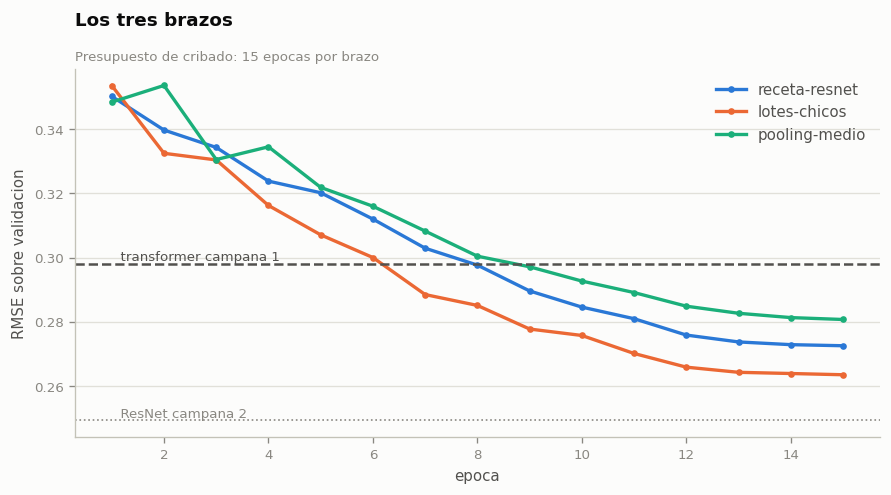

In [9]:
import matplotlib.pyplot as plt
from chessdl import viz

viz.apply_style()
fig, ax = plt.subplots()
for i, (nombre, run) in enumerate(barrido.runs.items()):
    ep = [e.epoch for e in run.history.epochs]
    ax.plot(ep, [e.val_rmse for e in run.history.epochs],
            marker='o', markersize=3, color=viz.SERIES[i % len(viz.SERIES)], label=nombre)
ax.axhline(REFERENCIA, color=viz.INK_SECONDARY, linestyle='--', linewidth=1.5)
ax.text(1, REFERENCIA, '  transformer campana 1', color=viz.INK_SECONDARY, fontsize=8, va='bottom')
ax.axhline(0.2494, color=viz.INK_MUTED, linestyle=':', linewidth=1)
ax.text(1, 0.2494, '  ResNet campana 2', color=viz.INK_MUTED, fontsize=8, va='bottom')
ax.legend(loc='upper right')
viz.label_axes(ax, 'Los tres brazos', 'epoca', 'RMSE sobre validacion',
               note='Presupuesto de cribado: 15 epocas por brazo')
fig.tight_layout()

## 6. Campaña final

El ganador, ahora a **30 épocas** — el mismo presupuesto que la campaña 1 del
transformer y que la campaña 2 de la ResNet. Eso es lo que hace que los tres
números de la tabla final se puedan poner uno al lado del otro.

Igual que en la tarea 4.6, se confirma en vez de adoptarse directo, y acá el
motivo es concreto: **los dos brazos no-control tenían ventaja a 15 épocas.**
`lotes-chicos` por sus 67.320 actualizaciones contra 33.660, y `pooling-medio`
porque el gradiente directo a las 64 casillas acelera el arranque. Las dos
ventajas se comprimen con más entrenamiento.

**Qué resuelve esta campaña y qué no.** Resuelve lo que importa para la
comparación con la ResNet: cuánto rinde la mejor configuración del transformer
con el presupuesto completo, medido contra la campaña 1 y contra la ResNet.

Lo que *no* resuelve, si el ganador no es `receta-resnet`, es la atribución:
para separar "la técnica es mejor" de "el cribado la premió" haría falta correr
también el control a 30 épocas, otras ~6 h. Queda anotado como limitación, y la
celda de abajo permite hacerlo cambiando un nombre si el resultado lo amerita.

In [10]:
from chessdl.training.checkpoint import HubCheckpoints
from chessdl.training.loop import seed_everything, train

EPOCAS_FINAL = 30

# Para confirmar el control en vez del ganador (ver la limitacion de arriba),
# poner BRAZO_FINAL = 'receta-resnet' y volver a correr desde aca.
BRAZO_FINAL = barrido.best_name()

ganador = barrido.experiments[BRAZO_FINAL]
print(f'Confirmando: {ganador.name} -- {ganador.rationale}')
print(f'Cambia: {ganador.overrides()}')
if BRAZO_FINAL != 'receta-resnet':
    print()
    print('Ojo: el ganador no es el control, asi que este numero mide cuanto rinde')
    print('la mejor configuracion, no a que tecnica se le debe la mejora.')

config_final = ganador.model_config(arquitectura)
seed_everything(cfg.training.split_seed)
modelo = ChessTransformer(config_final)
print(modelo.describe())

Confirmando: lotes-chicos -- lote 512: el doble de pasos de optimizacion por epoca
Cambia: {'batch_size': 512, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 2, 'grad_clip': 1.0}

Ojo: el ganador no es el control, asi que este numero mide cuanto rinde
la mejor configuracion, no a que tecnica se le debe la mejora.
Transformer d_model 192 x 6 capas x 8 cabezas (ffn 768, pooling cls, dropout 0.0) -- 2,735,361 parametros


In [11]:
checkpoints = HubCheckpoints(
    repo_id=repo_modelos,
    run_name=f'transformer-campana2-{BRAZO_FINAL}',
    local_dir='/content/ceia-chess/checkpoints',
    token=token,
    enabled=cfg.training.push_to_hub and token is not None,
)

ajustes = dict(
    epochs=EPOCAS_FINAL,
    batch_size=cfg.training.batch_size,
    loss_name=cfg.training.loss,
    seed=cfg.training.split_seed,
)
ajustes.update(ganador.overrides())
ajustes['epochs'] = EPOCAS_FINAL   # el presupuesto lo fija la campana, no el brazo

campana2 = train(
    modelo, cache, targets, idx_train, idx_val,
    checkpoints=checkpoints,
    model_config=transformer_summary(config_final),
    baselines=pisos,
    **ajustes,
)
print()
print(campana2.summary())

transformer-campana2-lotes-chicos/checkp(…): reconstructing file:   0%|          |  0.00B / 32.9MB            

transformer-campana2-lotes-chicos/checkp(…): downloading bytes:           |  0.00B            

Reanudando desde la epoca 22.


epoca 23:   0%|          | 0/4488 [00:00<?, ?lote/s]

epoca  23  perdida 0.04460  RMSE 0.2542  MAE 0.1610  MAEcp  105.5  signo 87.5%  rho 0.8327


...

epoca  30  perdida 0.03664  RMSE 0.2594  MAE 0.1611  MAEcp  105.7  signo 87.6%  rho 0.8285


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...chicos/checkpoint_last.pt:   2%|1         |  553kB / 32.9MB            


 epoca     train   val RMSE   val MAE   MAE cp    signo     rho     seg
-----------------------------------------------------------------------
     1   0.13980     0.3537    0.2605    157.0   74.5%  0.6482     656
     2   0.12468     0.3325    0.2390    147.3   78.4%  0.6867     657
     3   0.11427     0.3305    0.2369    146.2   78.2%  0.6921     658
     4   0.10565     0.3192    0.2259    139.6   79.4%  0.7102     658
     5   0.09867     0.3069    0.2144    133.5   81.0%  0.7363     657
     6   0.09179     0.2997    0.2119    133.2   81.9%  0.7568     659
     7   0.08670     0.2895    0.1998    126.5   83.2%  0.7706     659
     8   0.08258     0.2878    0.1951    123.4   83.2%  0.7783     659
     9   0.07905     0.2782    0.1873    119.4   84.5%  0.7904     659
    10   0.07573     0.2775    0.1876    119.8   84.6%  0.7917     659
    11   0.07251     0.2688    0.1799    115.9   85.6%  0.8062     657
    12   0.06937     0.2660    0.1777    114.6   85.5%  0.8114     657
   

## 7. Evaluación final sobre test

El split de test se toca **una sola vez**, con el mejor checkpoint por
validación de esta campaña.

In [12]:
from chessdl.training.checkpoint import BEST_NAME, load_checkpoint
from chessdl.training.loop import evaluate_split

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
mejor = checkpoints.fetch(BEST_NAME)
if mejor is not None:
    load_checkpoint(mejor, modelo, map_location=dispositivo)
modelo = modelo.to(dispositivo)

test_tr2 = evaluate_split(modelo, cache, targets, idx_test, dispositivo)
print('TEST -- transformer campana 2')
print(test_tr2.summary())

transformer-campana2-lotes-chicos/checkp(…): reconstructing file:   0%|          |  0.00B / 32.9MB            

transformer-campana2-lotes-chicos/checkp(…): downloading bytes:           |  0.00B            

TEST -- transformer campana 2
posiciones                     127,499
RMSE (value)                    0.2531
MAE (value)                     0.1663
MAE (centipeones)                109.0
acuerdo de signo               86.80%
Spearman                        0.8315


## 8. Atención contra convolución: el resultado

In [13]:
TEST_RESNET_C1     = 0.2609   # notebook 04
TEST_RESNET_C2     = 0.2511   # notebook 05
TEST_TRANSFORMER_1 = 0.2978   # notebook 06

print(f"{'':<36}{'RMSE':>10}{'R2':>10}{'params':>12}")
print('-' * 70)
filas = [('media constante', pisos['media'], None),
         ('material lineal', pisos['material'], None),
         ('ResNet campana 1', TEST_RESNET_C1, 2913345),
         ('ResNet campana 2', TEST_RESNET_C2, 2913345),
         ('Transformer campana 1', TEST_TRANSFORMER_1, 2735361),
         ('Transformer campana 2', test_tr2.rmse, modelo.count_parameters())]
for nombre, valor, params in filas:
    p = f'{params:>12,}' if params else f'{"--":>12}'
    print(f'{nombre:<36}{valor:>10.4f}{1-(valor/pisos["media"])**2:>10.3f}{p}')

interno = (TEST_TRANSFORMER_1 - test_tr2.rmse) / TEST_TRANSFORMER_1
contra  = (TEST_RESNET_C2 - test_tr2.rmse) / TEST_RESNET_C2
print()
print(f'Contra su propia campana 1: {"mejora" if interno > 0 else "EMPEORA"} {abs(interno):.2%}')
print(f'Contra la mejor ResNet:     {"mejora" if contra > 0 else "EMPEORA"} {abs(contra):.2%}')
print()
if contra > 0.01:
    print('Gana la atencion. Con presupuestos de parametros equiparados y la misma')
    print('receta de entrenamiento, leer el tablero como 64 casillas que se miran')
    print('entre si rinde mas que leerlo con ventanas de 3x3.')
elif contra > -0.03:
    print('Empate tecnico. Las dos arquitecturas llegan al mismo lugar con el mismo')
    print('presupuesto, lo que sugiere que el limite no esta en como se lee el')
    print('tablero sino en los datos: se consumio el 47 % del extracto disponible.')
else:
    print('Gana la ResNet, y ahora con el transformer ajustado la conclusion se')
    print('sostiene: la convolucion trae la localidad de fabrica, y a esta escala')
    print('de datos la atencion no alcanza a aprender la geometria del tablero.')
print()
print('Costo, que la tabla de parametros no muestra: el transformer tarda ~12,4 min')
print('por epoca contra los ~3,8 de la ResNet. Equiparados en parametros y epocas,')
print('NO lo estan en computo: 3,2 veces mas GPU por el mismo recorrido de datos.')
print()
print(f'Pesos y metricas: https://huggingface.co/{repo_modelos}')

                                          RMSE        R2      params
----------------------------------------------------------------------
media constante                         0.4886     0.000          --
material lineal                         0.3973     0.339          --
ResNet campana 1                        0.2609     0.715   2,913,345
ResNet campana 2                        0.2511     0.736   2,913,345
Transformer campana 1                   0.2978     0.628   2,735,361
Transformer campana 2                   0.2531     0.732   2,735,361

Contra su propia campana 1: mejora 15.02%
Contra la mejor ResNet:     EMPEORA 0.78%

Empate tecnico. Las dos arquitecturas llegan al mismo lugar con el mismo
presupuesto, lo que sugiere que el limite no esta en como se lee el
tablero sino en los datos: se consumio el 47 % del extracto disponible.

Costo, que la tabla de parametros no muestra: el transformer tarda ~12,4 min
por epoca contra los ~3,8 de la ResNet. Equiparados en parametros y e

**Próximo paso:** `08_motor_y_partidas.ipynb` — el motor de juego y su evaluación contra Stockfish (bloques 5 y 6), que es donde se mide cuánto *juegan* estos modelos y no solo cuánto se parecen a Stockfish.